In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.stats import ks_2samp
from pathlib import Path
import os

cwd = Path.cwd()
parent = cwd.parent

In [6]:
%matplotlib widget

In [7]:
def determine_sample_color(x):
    ''' 
    Find to which macrostate the last sample belongs (Kp, P+L,P,A+D,A) and choose a color accordingly.
    '''

    ### Kp, Km, A, P, D, L is the correct order   
    if x[2]>0.05: #Alcaligenes present
        if x[4]<0.01: #Delftia absent
            cluster = 2
        else:
            cluster = 4
    elif x[3]>0.05: #Pseudomonas present
        if x[5]<0.01: #lachnoclostridium absent
            cluster = 3
        else:
            cluster = 5
            # print(x[5],x[7])
    else: #both alcaligenes and pseudomonas absent
        cluster = 0
    ### There is no cluster 1 no enterotype dominated only by Km.
    return cluster

In [8]:
color_scheme = np.array([(0,122,159), #Kp
          (90,165,202), #Km
          (255,196,69), #Alcaligenes
          (187,143,198), #pseudomonas
          (248,106,106), #Delftia
          (185,218,219), #lachnocrostidium
    ])/255

In [11]:
dataset = 'Estrella_full'
dataset_name = dataset
dataset_label = 'Estrela'
with open('../out/{}/low_variance_eigvals.{}.dat'.format(dataset,dataset),
          'rb') as f:
    lowvar_eigvals = pickle.load(f) #(N_species,N_vectors)
    N_low = len(lowvar_eigvals)
    f.close()
with open('../out/{}/high_variance_eigvals.{}.dat'.format(dataset,dataset),
          'rb') as f:
    highvar_eigvals = pickle.load(f)
    N_high = len(highvar_eigvals)
    f.close()
with open('../out/{}/eigvals.{}.dat'.format(dataset,dataset),
          'rb') as f:
    eigvals = pickle.load(f)
    N_total = len(eigvals)
    f.close()
with open('../out/{}/full_dataset.filtered.{}.dat'.format(dataset,dataset),
          'rb') as f:
    full_dataset = pickle.load(f)
    M,N = np.shape(full_dataset)
    print(M,N)
    f.close()

with open('../out/{}/low_variance_eigenmodes.{}.dat'.format(dataset,dataset),
          'rb') as f:
    low_variance_eigenmodes = pickle.load(f)
    f.close()

if M<N:
    eigvals = eigvals[-(M-1):]

276 14


In [12]:
means = np.mean(full_dataset,axis=0)
stds = np.std(full_dataset,axis=0)

In [13]:
clusters = [determine_sample_color(x) for x in full_dataset]
colors = [color_scheme[i] for i in clusters]
colors = np.array(colors); clusters = np.array(clusters)

zscored_data = (full_dataset-means[None,:])/stds[None,:]

-0.6868258734631855
0.4652472892483321


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_41616\970133042.py:84: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pos_mean_cluster,
C:\Users\Lenovo\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Lenovo\anaconda3\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Lenovo\anaconda3\lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Lenovo\anaconda3\lib\site-packages\numpy\core\_m

-0.23355243221846622
0.5706320507129494
-0.6089347098528861
0.6983229806432635


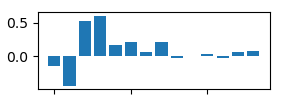

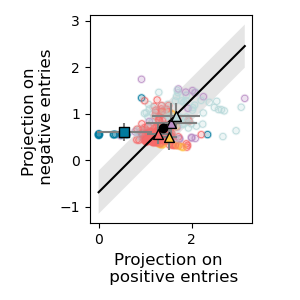

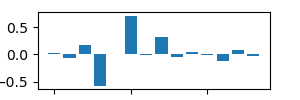

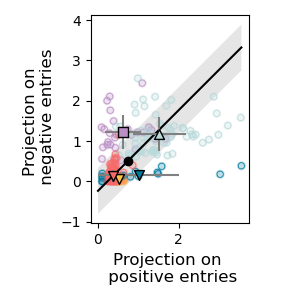

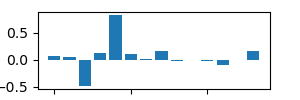

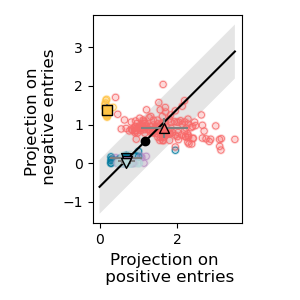

In [14]:
plt.close('all')
for mode,vect in enumerate(low_variance_eigenmodes.T):
    if mode==0: continue #relative abundance mode
    if mode==2: vect = -vect #to keep sign convention wrt production/consumption
    fig,ax = plt.subplots(figsize=(3,1))
    ax.bar(range(N),
           vect)

    fig,ax = plt.subplots(figsize=(3,3))

    ''' Get positive and negative part '''
    pos = vect>0
    neg = vect<=0 #since we have reals, equality will never truly occur    
    pos_part = (full_dataset)[:,pos]@(vect/stds[:])[pos]
    neg_part = (full_dataset)[:,neg]@(vect/stds[:])[neg]

    ax.scatter((pos_part),
               -(neg_part),
              # c=colors,edgecolor=colors, #as in the final figure
              # alpha=0.8,s=30,#as in the final figure
              # c=colors,edgecolor=colors*0.8,alpha =0.8,s=10,
               edgecolor = colors,facecolor='none',alpha = 1,s=20,linewidth=0.5,
              )
    ax.scatter((pos_part),
               -(neg_part),
              # c=colors,edgecolor=colors, #as in the final figure
              # alpha=0.8,s=30,#as in the final figure
              # c=colors,edgecolor=colors*0.8,alpha =0.8,s=10,
               facecolor=colors,alpha = 0.25,s=30,
              )

    ''' mean projection on mode '''
    complete_projection = (zscored_data)@vect
    mean_pos = np.mean(pos_part)
    mean_neg = np.abs(np.mean(neg_part))
    print(mean_neg-mean_pos)
    ax.scatter(mean_pos,mean_neg,
               c='k',zorder=10)

    ymax = np.max((np.abs(pos_part),np.abs(neg_part)))#+np.abs(neg_part))
    xvect = np.linspace(0,ymax,100)

    ''' Confidence Interval, as mean line +- standard deviation '''
    eigval = eigvals[mode]
    spread = np.sqrt(eigval/2) #standard deviation in the direction perpendicular to the black line
    shift = spread/np.cos(np.pi/4) #x, or y, shift in the edge line wrt the central line  
    print(shift)
    ax.plot(xvect,mean_neg+(xvect-mean_pos),'k-')
    ax.fill_between(xvect,
                    mean_neg+(xvect-mean_pos)-shift,
                    mean_neg+(xvect-mean_pos)+shift,
                    facecolor='gray',zorder=0,
                    alpha=0.2)

    ''' Get mean projection per enterotype '''
    for i in range(np.max(clusters)+1):
        cluster = np.array(clusters)==i
        pos_part_cluster = pos_part[cluster]
        neg_part_cluster = neg_part[cluster]

        pos_mean_cluster = np.mean(pos_part_cluster)
        neg_mean_cluster = np.mean(neg_part_cluster)
        pos_std_cluster = np.std(pos_part_cluster)
        neg_std_cluster = np.std(neg_part_cluster)

        ax.errorbar(pos_mean_cluster,
                    -neg_mean_cluster,
                    yerr = neg_std_cluster,
                    xerr = pos_std_cluster,
                    linestyle = '',
                    ecolor='gray')
        ''' Select marker, for each LC and enterotype, based on the taxa that are alive/dead '''
        if mode==1: #cross feeding between Km,Kp and A,P
            if i==0: marker = 's'
            else: marker='^'
        elif mode==2: #x-feeding between P and L
            if i==3: marker = 's'
            elif i==5: marker = '^'
            else: marker= 'v'
        elif mode==3:
            if i==2: marker = 's'
            elif i==4: marker = '^'
            else: marker = 'v'
        ax.scatter(pos_mean_cluster,
                -neg_mean_cluster,
                   edgecolor='k',
                   marker=marker,
                   c = color_scheme[i],
                   s= 50,zorder=3)
    

    
    # ax.plot(xvect,mean_neg+(xvect-mean_pos)-shift,'-',c='gray',)
    # ax.plot(xvect,mean_neg+(xvect-mean_pos)+shift,'-',c='gray',)

    # ax.set_xlabel(r'$|\vec{e}^+_\alpha \cdot \overrightarrow{n/\sigma}|$')
    # ax.set_ylabel(r'$|\vec{e}^-_\alpha \cdot \overrightarrow{n/\sigma}|$')
    if mode==0:
        ax.set_xlim(left=2.5)
        ax.set_ylim(bottom=-0.3)
    ax.set_xlabel('Projection on \n positive entries',fontsize=12)
    ax.set_ylabel('Projection on \n negative entries',fontsize=12)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig('PC_satisfaction.PC{}.{}.svg'.format(N-mode,dataset_name),format='svg',transparent=True)
    plt.savefig('PC_satisfaction.PC{}.{}.png'.format(N-mode,dataset_name),format='png',transparent=True)


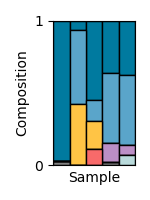

In [15]:
''' Plot some Particular Samples to show explicitly the different enterotypes '''
''' Choose representative samples of each macroscopic state '''
chosen_samples = [2, #Kp state
                  15, #A state
                  16, #A+D state
                  103, #P state
                  92 #P+L state
                 ]

horizontal = False
if horizontal:
    fig,ax = plt.subplots(figsize = (2,1.5))
    ax.barh(np.arange(len(chosen_samples)),
           full_dataset[chosen_samples,0],
           height=1,
           edgecolor='k',
           facecolor = color_scheme[0])
    for i in range(1,6):
        ax.barh(np.arange(len(chosen_samples)),
           full_dataset[chosen_samples,i],
            left = np.cumsum(full_dataset[chosen_samples,:],axis=1)[:,i-1],
           height=1,
           edgecolor='k',
           facecolor = color_scheme[i])
    ax.barh(np.arange(len(chosen_samples)),
           np.cumsum(full_dataset[chosen_samples,:],axis=1)[:,-1],
           height=1,
           edgecolor='k',
           facecolor = 'gray',
          zorder=0)
    ax.set_xlim(right=1)
    ax.set_ylim(bottom=4.5,top=-0.5)
    ax.set_yticks([])
    ax.set_ylabel('Sample')
    ax.set_xlabel('Composition')
else:
    fig,ax = plt.subplots(figsize = (1.5,2))
    ax.bar(np.arange(len(chosen_samples)),
           full_dataset[chosen_samples,0],
           width=1,
           edgecolor='k',
           facecolor = color_scheme[0])
    for i in range(1,6):
        ax.bar(np.arange(len(chosen_samples)),
           full_dataset[chosen_samples,i],
            bottom = np.cumsum(full_dataset[chosen_samples,:],axis=1)[:,i-1],
           width=1,
           edgecolor='k',
           facecolor = color_scheme[i])
    ax.bar(np.arange(len(chosen_samples)),
           np.cumsum(full_dataset[chosen_samples,:],axis=1)[:,-1],
           width=1,
           edgecolor='k',
           facecolor = 'gray',
          zorder=0)
    ax.yaxis.set_inverted(True)
    ax.set_yticks([0,1])
    ax.set_yticklabels([1,0])
    ax.set_ylim(bottom=1)
    ax.set_xlim(right=4.5,left=-0.5)
    ax.set_xticks([])
    ax.set_xlabel('Sample')
    ax.set_ylabel('Composition')

plt.tight_layout()
plt.savefig('representative_samples.{}.svg'.format(dataset_name),transparent=True,format='svg')